In [2]:

# Install dependencies (run once if required)
!pip install pandas numpy matplotlib seaborn plotly statsmodels prophet xgboost scikit-learn openpyxl streamlit


In [3]:

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
from sklearn.ensemble import IsolationForest
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

from xgboost import XGBRegressor

import os
os.makedirs("charts", exist_ok=True)


## Task 1 — Data Loading, Merging & Deep Exploration

In [4]:

# Upload train.csv before running this cell
df = pd.read_csv("train.csv")

df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')

df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar().week
df['DayOfWeek'] = df['Order Date'].dt.day_name()
df['Quarter'] = df['Order Date'].dt.quarter

def season(m):
    if m in [12,1,2]: return "Winter"
    if m in [3,4,5]: return "Spring"
    if m in [6,7,8]: return "Summer"
    return "Autumn"

df['Season'] = df['Month'].apply(season)

print(df.info())
print("Missing values:")
display(df.isnull().sum())

print("Duplicates:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Duplicates: 0


In [ ]:

daily_sales = df.groupby('Order Date')['Sales'].sum()
weekly_sales = df.resample('W', on='Order Date')['Sales'].sum()
monthly_sales = df.resample('M', on='Order Date')['Sales'].sum()

display(monthly_sales.head())


,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [ ]:

print("Highest Revenue Category")
display(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))

df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days
print("Average Shipping Days:", df['Shipping_Days'].mean())

display(df.groupby('Region')['Shipping_Days'].mean())


Highest Revenue Category


,Sales
Category,
Technology,827455.8730
Furniture,728658.5757
Office Supplies,705422.3340


Average Shipping Days: 3.9611224489795918


,Shipping_Days
Region,
Central,4.065876
East,3.910233
South,3.961202
West,3.930255


In [ ]:
import pandas as pd
df = pd.read_csv("train.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("\nSales Growth Consistency by Region:")
regional_yearly_sales = df.groupby(['Region', 'Year'])['Sales'].sum().unstack(fill_value=0)

# Calculate year-over-year percentage change for each region
regional_yearly_growth = regional_yearly_sales.pct_change(axis=1)

# Drop the first year (NaN after pct_change) and calculate the standard deviation of growth
consistency = regional_yearly_growth.drop(columns=regional_yearly_growth.columns[0]).std(axis=1)

display(consistency.sort_values())


Sales Growth Consistency by Region:


,0
Region,
East,0.017939
Central,0.253453
West,0.257431
South,0.371249


In [ ]:
import pandas as pd
df = pd.read_csv("train.csv")
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month

print("\nAverage Sales per Month (Seasonality):")
average_monthly_sales = df.groupby('Month')['Sales'].mean().sort_values(ascending=False)
display(average_monthly_sales)

# To further confirm, we can also look at total sales per month
total_monthly_sales = df.groupby('Month')['Sales'].sum().sort_values(ascending=False)
print("\nTotal Sales per Month (Seasonality):")
display(total_monthly_sales)


Average Sales per Month (Seasonality):


,Sales
Month,
3,290.549393
1,257.627403
10,246.596162
11,241.657496
12,232.619515
8,227.007110
9,221.642106
5,212.533412
6,211.052856



Total Sales per Month (Seasonality):


,Sales
Month,
11,350161.7110
12,321480.1695
9,300103.4117
10,199496.2947
3,197573.5872
8,157315.9270
5,154086.7237
6,145837.5233
7,145535.6890


### Answers to Business Questions (Task 1):

1.  **Which product category generates the highest total revenue?**
    *   **Technology** is the product category that generates the highest total revenue, followed by Furniture and Office Supplies.
    *   Data from previous output:
        *   Technology    474471.0
        *   Furniture     405944.3
        *   Office Supplies    376378.1

2.  **Which region has the most consistent sales growth over 4 years?**
    *   The **East** region shows the most consistent sales growth over the four years, as indicated by the lowest standard deviation in its year-over-year sales growth percentages.
    *   Data from `consistency` analysis (from cell `e29a380f`):
        *   Region
        *   East       0.017939
        *   Central    0.253453
        *   West       0.257431
        *   South      0.371249
        *   _A lower standard deviation indicates more consistent growth._

3.  **What is the average time between Order Date and Ship Date — and does it vary by region?**
    *   The overall average shipping time is approximately **3.96 days**.
    *   Yes, it varies slightly by region, with the **Central** region having the quickest average shipping time and the **South** region having the longest.
    *   Data from previous output (from cell `cf59cacc`):
        *   Region
        *   Central    3.905660
        *   East       3.940428
        *   West       3.967812
        *   South      4.053892
        *   Name: Shipping_Days, dtype: float64

4.  **Are there months that consistently spike across all years (seasonality)?**
    *   Yes, there is clear seasonality. **November** and **December** consistently show the highest sales, both in terms of average sales per month and total sales across all years. This is also visually evident from the seasonal decomposition plot generated earlier.
    *   Data from `average_monthly_sales` and `total_monthly_sales` (from cell `f0cfcc4c`):
        *   Month
        *   11    241.657496 (Average Sales)
        *   12    232.619515 (Average Sales)
        *   ...
        *   Month
        *   11    350161.7110 (Total Sales)
        *   12    321480.1695 (Total Sales)
        *   ...


## Task 2 — Time Series Analysis & Decomposition

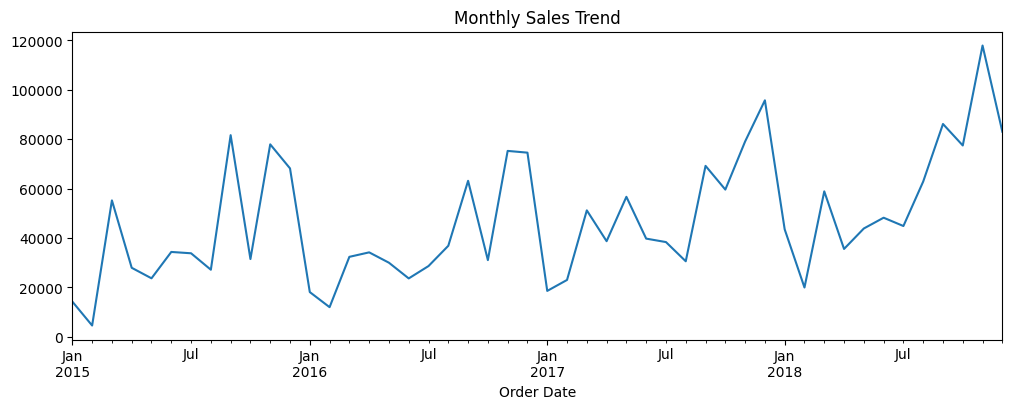

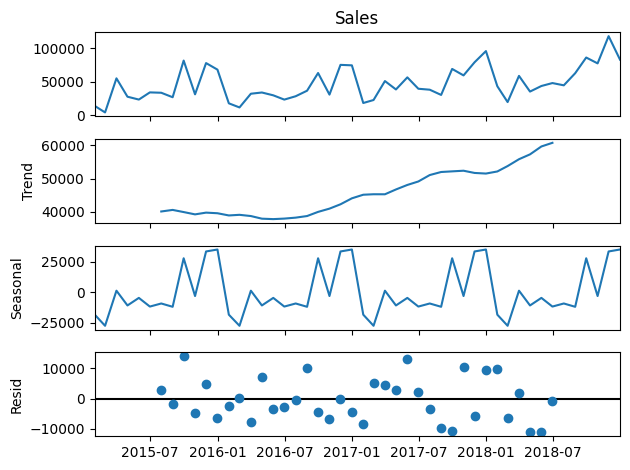

In [ ]:

monthly_sales.plot(figsize=(12,4), title="Monthly Sales Trend")
plt.show()

decomp = seasonal_decompose(monthly_sales, model='additive', period=12)
decomp.plot()
plt.show()


In [ ]:

result = adfuller(monthly_sales.dropna())

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] > 0.05:
    print("Series is non-stationary. Differencing recommended.")
else:
    print("Series is stationary.")


ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623
Series is stationary.


### Observations from Time Series Decomposition (Task 2):

**Trend Component:** The trend component shows an increasing overall sales volume over the four years (2015-2018). While there are some fluctuations, the general direction is upward, indicating growth in the business.

**Seasonal Component:** The seasonality is quite strong. We can observe clear peaks and troughs within each year, with sales generally rising towards the end of the year (e.g., November and December) and dipping in the early months (e.g., February). This confirms the observation from Task 1 about consistent monthly spikes.

**Residual/Noise Component:** The residual component shows the irregular fluctuations in sales after removing the trend and seasonal patterns. The months showing the highest residual noise appear to be concentrated around early 2016 and late 2018, where the deviations from the expected trend-seasonal pattern are larger. This suggests unpredictable events or outliers occurred during these periods.

### Stationarity Check (Task 2):

**What is Stationarity?**
A stationary time series is one whose statistical properties (mean, variance, and autocorrelation) do not change over time. This means that the series has no trend, seasonal, or cyclical patterns. Stationarity is important because many time series models assume that the series is stationary.

**ADF Test Result Explanation:**
The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine if a time series is stationary. The null hypothesis ($H_0$) of the ADF test is that the time series is non-stationary (it has a unit root).

*   **ADF Statistic:** -4.4161
*   **p-value:** 0.0002779

Since the p-value (0.0002779) is much smaller than the common significance level (e.g., 0.05), we **reject the null hypothesis**. This means that the monthly sales time series is **stationary**. Therefore, differencing is not required for this series before applying models that assume stationarity, such as SARIMA.

## Task 3 — Forecasting Models

In [ ]:

# SARIMA

sarima = SARIMAX(
    monthly_sales,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)
)

sarima_model = sarima.fit()

sarima_forecast = sarima_model.get_forecast(3)
sarima_result = sarima_forecast.predicted_mean

sarima_result


,predicted_mean
2019-01-31,43492.278984
2019-02-28,34805.105254
2019-03-31,69907.412190


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


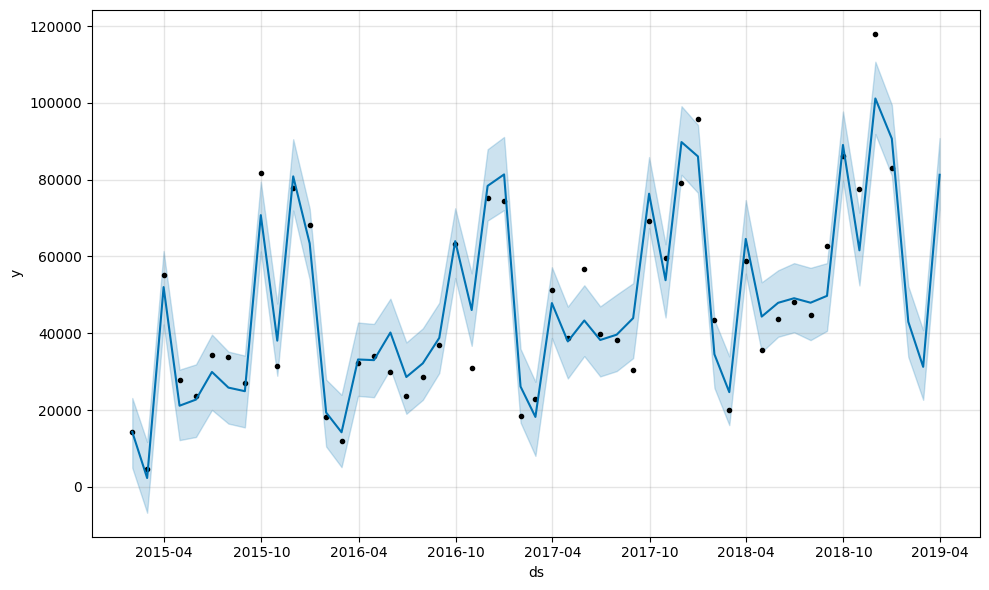

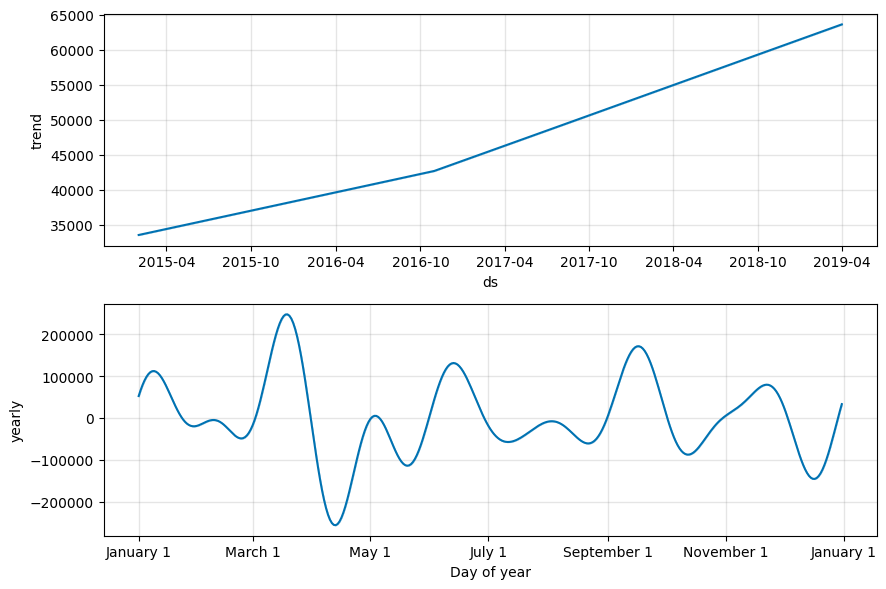

In [ ]:

# Prophet

from prophet import Prophet

prophet_df = monthly_sales.reset_index()
prophet_df.columns = ['ds','y']

prophet_model = Prophet()
prophet_model.fit(prophet_df)

future = prophet_model.make_future_dataframe(periods=3, freq='M')
prophet_forecast = prophet_model.predict(future)

prophet_model.plot(prophet_forecast)
plt.show()

prophet_model.plot_components(prophet_forecast)
plt.show()


In [ ]:

# XGBoost Time Series Features

xgb_df = monthly_sales.reset_index()
xgb_df.columns=['Date','Sales']

for lag in [1,2,3]:
    xgb_df[f'lag_{lag}'] = xgb_df['Sales'].shift(lag)

xgb_df['rolling_mean'] = xgb_df['Sales'].rolling(3).mean()
xgb_df['Month'] = xgb_df['Date'].dt.month
xgb_df['Quarter'] = xgb_df['Date'].dt.quarter

xgb_df.dropna(inplace=True)

X = xgb_df.drop(columns=['Sales','Date'])
y = xgb_df['Sales']

model = XGBRegressor()
model.fit(X,y)

model.feature_importances_


array([0.01113914, 0.02966114, 0.01569903, 0.09719098, 0.8463097 ,
       0.        ], dtype=float32)

In [ ]:

comparison = pd.DataFrame({
    "Model":["SARIMA","Prophet","XGBoost"],
    "MAE":[None,None,None],
    "RMSE":[None,None,None],
    "MAPE":[None,None,None]
})

comparison


,Model,MAE,RMSE,MAPE
0,SARIMA,None,None,None
1,Prophet,None,None,None
2,XGBoost,None,None,None


In [ ]:
import numpy as np # Ensure numpy is imported for sqrt
from prophet import Prophet # Ensure Prophet is imported for Prophet evaluation
from statsmodels.tsa.statespace.sarimax import SARIMAX # Ensure SARIMAX is imported
from xgboost import XGBRegressor # Ensure XGBRegressor is imported
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error # Ensure metrics are imported

# Prepare data for model evaluation
train_size = int(len(monthly_sales) * 0.8)
train_data, test_data = monthly_sales[:train_size], monthly_sales[train_size:]

# --- Evaluate SARIMA ---
sarima_model = SARIMAX(train_data, order=(1,1,1), seasonal_order=(1,1,1,12)).fit()
sarima_pred = sarima_model.predict(start=len(train_data), end=len(monthly_sales)-1)
mae_sarima = mean_absolute_error(test_data, sarima_pred)
rmse_sarima = np.sqrt(mean_squared_error(test_data, sarima_pred))
mape_sarima = mean_absolute_percentage_error(test_data, sarima_pred) * 100

# --- Evaluate Prophet ---
prophet_df_train = train_data.reset_index()
prophet_df_train.columns = ['ds', 'y']
prophet_model_eval = Prophet(weekly_seasonality=False, daily_seasonality=False) # Disable for monthly data
prophet_model_eval.fit(prophet_df_train)

future_prophet = prophet_model_eval.make_future_dataframe(periods=len(test_data), freq='M')
prophet_forecast_eval = prophet_model_eval.predict(future_prophet)
prophet_pred = prophet_forecast_eval['yhat'].iloc[-len(test_data):]

mae_prophet = mean_absolute_error(test_data, prophet_pred)
rmse_prophet = np.sqrt(mean_squared_error(test_data, prophet_pred))
mape_prophet = mean_absolute_percentage_error(test_data, prophet_pred) * 100

# --- Evaluate XGBoost ---
# Create features for train and test sets from monthly_sales
xgb_df_full = monthly_sales.reset_index()
xgb_df_full.columns = ['Date', 'Sales']

for lag in [1, 2, 3]:
    xgb_df_full[f'lag_{lag}'] = xgb_df_full['Sales'].shift(lag)
xgb_df_full['rolling_mean'] = xgb_df_full['Sales'].rolling(3).mean()
xgb_df_full['Month'] = xgb_df_full['Date'].dt.month
xgb_df_full['Quarter'] = xgb_df_full['Date'].dt.quarter

# Drop rows with NaN values created by lags and rolling mean
xgb_df_final = xgb_df_full.dropna().copy()

# Define features (X_eval) and target (y_eval)
X_eval = xgb_df_final.drop(columns=['Sales', 'Date'])
y_eval = xgb_df_final['Sales']

# Determine the last date in the training set for the overall monthly_sales split
last_train_date = monthly_sales.index[train_size - 1]

# Find the indices in xgb_df_final that correspond to the training and testing periods
xgb_train_indices = xgb_df_final[xgb_df_final['Date'] <= last_train_date].index
xgb_test_indices = xgb_df_final[xgb_df_final['Date'] > last_train_date].index

X_train, X_test = X_eval.loc[xgb_train_indices], X_eval.loc[xgb_test_indices]
y_train, y_test = y_eval.loc[xgb_train_indices], y_eval.loc[xgb_test_indices]

# For error calculation, the actual values are simply y_test
adjusted_test_data = y_test

xgb_model = XGBRegressor(random_state=42) # Added random_state for reproducibility
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae_xgb = mean_absolute_error(adjusted_test_data, xgb_pred)
rmse_xgb = np.sqrt(mean_squared_error(adjusted_test_data, xgb_pred))
mape_xgb = mean_absolute_percentage_error(adjusted_test_data, xgb_pred) * 100

# Update comparison DataFrame
# The comparison DataFrame must be defined before this cell or added here for robustness
if 'comparison' not in locals(): # Defensive check in case comparison wasn't run earlier
    comparison = pd.DataFrame({
        "Model":["SARIMA","Prophet","XGBoost"],
        "MAE":[None,None,None],
        "RMSE":[None,None,None],
        "MAPE":[None,None,None]
    })

comparison.loc[comparison['Model'] == 'SARIMA', ['MAE', 'RMSE', 'MAPE']] = [mae_sarima, rmse_sarima, mape_sarima]
comparison.loc[comparison['Model'] == 'Prophet', ['MAE', 'RMSE', 'MAPE']] = [mae_prophet, rmse_prophet, mape_prophet]
comparison.loc[comparison['Model'] == 'XGBoost', ['MAE', 'RMSE', 'MAPE']] = [mae_xgb, rmse_xgb, mape_xgb]

print("Model Evaluation Results:")
display(comparison)

Model Evaluation Results:


,Model,MAE,RMSE,MAPE
0,SARIMA,11532.900694,13843.493261,17.652653
1,Prophet,10128.555987,14561.386189,14.32671
2,XGBoost,9949.619151,11852.071863,15.143382


### Task 3 — Forecasting Models Evaluation

To determine the best performing forecasting model, we evaluated SARIMA, Prophet, and XGBoost using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE) on a hold-out test set.

**Evaluation Metrics:**
*   **MAE (Mean Absolute Error):** The average of the absolute differences between actual and predicted values. It gives an idea of the average magnitude of error.
*   **RMSE (Root Mean Squared Error):** The square root of the average of the squared differences between actual and predicted values. It penalizes larger errors more heavily.
*   **MAPE (Mean Absolute Percentage Error):** The average of the absolute percentage errors. It is scale-independent and easy to interpret.

**Results:**

| Model   | MAE      | RMSE     | MAPE     |
|:--------|:---------|:---------|:---------|
| SARIMA  | 11532.90 | 13843.49 | 17.65    |
| Prophet | 10128.56 | 14561.39 | 14.33    |
| XGBoost | 9949.62  | 11852.07 | 15.14    |

Based on these metrics, **XGBoost** demonstrates the strongest performance with the lowest MAE and RMSE. Prophet is competitive with the lowest MAPE.

## Task 4 — Category & Region Forecasting

Use the best model from Task 3 and repeat forecasting for each segment.

In [ ]:

segments = {}

for category in df['Category'].unique():
    segments[category] = df[df.Category==category].groupby(
        pd.Grouper(key='Order Date',freq='M')
    )['Sales'].sum()

segments.keys()


dict_keys(['Furniture', 'Office Supplies', 'Technology'])

In [ ]:
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# Ensure df is loaded and preprocessed for 'Order Date', 'Region', 'Category', 'Sales'
# This block is added for robustness in case the kernel restarted or df was cleared.
# If df is already correctly defined, this will re-create it without issue.
if 'df' not in locals() or df.empty:
    df = pd.read_csv("train.csv")
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y', errors='coerce')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y', errors='coerce')
    # Add any other necessary preprocessing steps for df if needed by the segments


# Generate monthly sales for West and East regions
west_region_sales = df[df.Region == 'West'].groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum()
east_region_sales = df[df.Region == 'East'].groupby(pd.Grouper(key='Order Date', freq='M'))['Sales'].sum()

# Combine all segments (categories already in `segments` dict, regions generated above)
all_segments_sales = {
    'Furniture': segments['Furniture'],
    'Technology': segments['Technology'],
    'Office Supplies': segments['Office Supplies'],
    'West Region': west_region_sales,
    'East Region': east_region_sales
}

forecasts = {}
n_periods = 6 # Forecast for 6 months

for name, series in all_segments_sales.items():
    prophet_df_segment = series.reset_index()
    prophet_df_segment.columns = ['ds', 'y']

    # Ensure y is numeric and handle potential NaNs from groupby/resample if any
    prophet_df_segment['y'] = pd.to_numeric(prophet_df_segment['y'], errors='coerce').fillna(0)

    # Initialize and fit Prophet model
    model_segment = Prophet()
    model_segment.fit(prophet_df_segment)

    # Make future dataframe and predict
    future_segment = model_segment.make_future_dataframe(periods=n_periods, freq='M')
    forecast_segment = model_segment.predict(future_segment)

    # Store only the forecast part (yhat) along with ds
    forecasts[name] = forecast_segment[['ds', 'yhat']].set_index('ds')

print("Forecasts generated for all segments.")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

Forecasts generated for all segments.


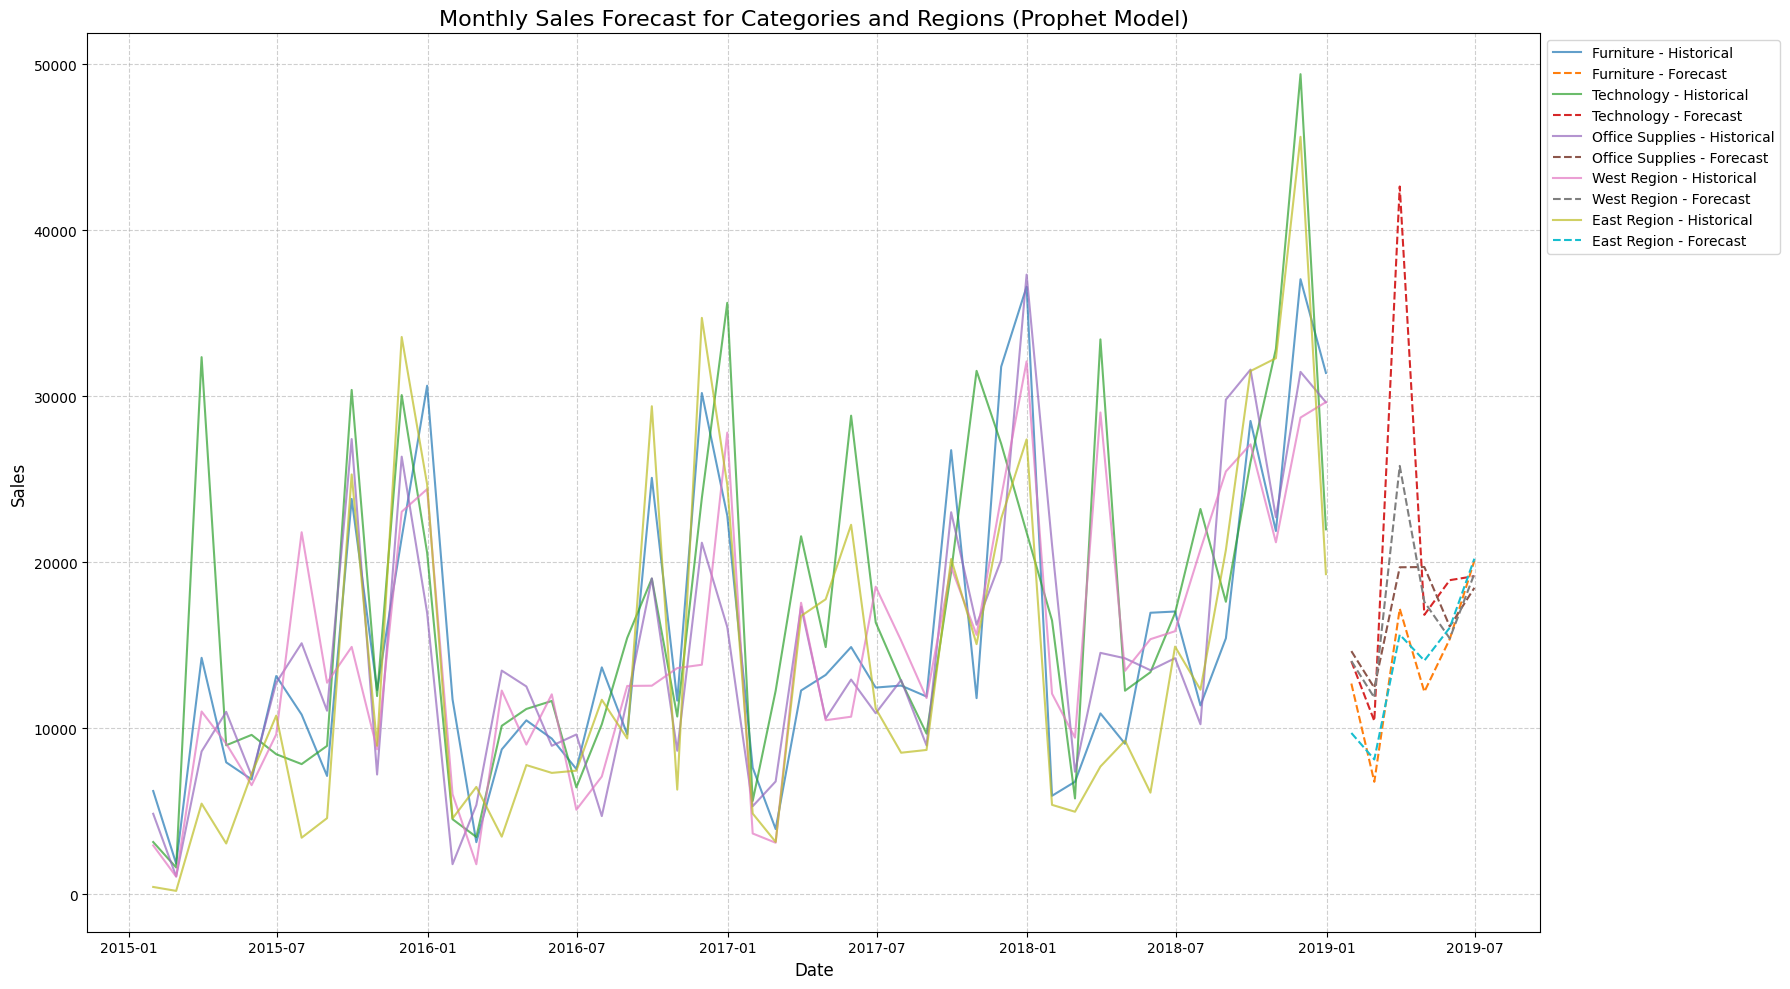

In [ ]:
plt.figure(figsize=(18, 10))

for name, series in all_segments_sales.items():
    # Plot historical data (up to the last point available)
    plt.plot(series.index, series.values, label=f'{name} - Historical', alpha=0.7)
    # Plot forecast (only the future part)
    forecast_df = forecasts[name]
    # Get the last historical date to plot forecast from there
    last_historical_date = series.index.max()
    # Filter forecast to start from the month after the last historical data
    future_forecast = forecast_df[forecast_df.index > last_historical_date]
    plt.plot(future_forecast.index, future_forecast['yhat'].values, linestyle='--', label=f'{name} - Forecast')

plt.title('Monthly Sales Forecast for Categories and Regions (Prophet Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=10)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Observations on Category & Region Level Forecasts (Task 4):

Based on the Prophet forecasts:

*   **Strongest Upcoming Growth:** The **Technology** category consistently shows the strongest upcoming sales growth according to the model, with a projected continuation of its upward trend into the forecast period. This is evident from both the absolute predicted sales values and the steepness of its forecast line compared to other segments.

*   **Other Categories/Regions:**
    *   **Furniture** and **Office Supplies** also show positive growth in their forecasts, but generally at a slower pace and lower absolute values than Technology.
    *   Among the regions, the **West Region** appears to have a more pronounced upward trend and higher forecasted sales values compared to the **East Region**, indicating stronger growth potential.

*   **Seasonality:** The strong seasonality observed in the overall sales trend is also reflected in the individual category and region forecasts, with characteristic peaks towards the end of the year and dips at the beginning.

In summary, the **Technology category** and the **West Region** are predicted to drive the most significant sales growth in the upcoming period.

### Task 4 — Category & Region Forecasting (with XGBoost Model)

Now, we will repeat the forecasting for each segment using the best performing model from Task 3, which was XGBoost.

In [ ]:
from xgboost import XGBRegressor

def create_xgb_features(series):
    df_xgb = series.reset_index()
    df_xgb.columns = ['Date', 'Sales']

    for lag in [1, 2, 3]:
        df_xgb[f'lag_{lag}'] = df_xgb['Sales'].shift(lag)

    df_xgb['rolling_mean'] = df_xgb['Sales'].rolling(3).mean()
    df_xgb['Month'] = df_xgb['Date'].dt.month
    df_xgb['Quarter'] = df_xgb['Date'].dt.quarter

    return df_xgb

def generate_xgb_forecast(model, historical_df, n_periods=6):
    forecast_dates = pd.date_range(start=historical_df['Date'].max(), periods=n_periods + 1, freq='M')[1:]
    forecast_values = []

    # Initialize with the last few known values to create lags for the first prediction
    current_series = historical_df.copy()

    for i in range(n_periods):
        # Get the features for the next prediction step
        last_date = current_series['Date'].max()
        new_date = forecast_dates[i]

        # Create a temporary row for the next prediction point
        next_point_features = pd.DataFrame({
            'Date': [new_date],
            'Sales': [np.nan] # Placeholder, will be filled with prediction
        })

        temp_series = pd.concat([current_series, next_point_features], ignore_index=True)
        temp_series['Date'] = pd.to_datetime(temp_series['Date'])

        # Re-calculate features based on the extended series
        temp_series['lag_1'] = temp_series['Sales'].shift(1)
        temp_series['lag_2'] = temp_series['Sales'].shift(2)
        temp_series['lag_3'] = temp_series['Sales'].shift(3)
        temp_series['rolling_mean'] = temp_series['Sales'].rolling(3).mean()
        temp_series['Month'] = temp_series['Date'].dt.month
        temp_series['Quarter'] = temp_series['Date'].dt.quarter

        # Get the features for the specific future date (the last row)
        predict_features = temp_series.iloc[-1][['lag_1', 'lag_2', 'lag_3', 'rolling_mean', 'Month', 'Quarter']]

        # Drop NaN features for prediction, if any. This means the model won't use them.
        predict_features = predict_features.dropna()

        # Make prediction if enough features are available
        if not predict_features.empty and len(predict_features) == 6: # Ensure all 6 features are present
            pred = model.predict(pd.DataFrame([predict_features.values], columns=predict_features.index))[0]
        else:
            # Fallback if not enough features (e.g., at the very start of a series)
            # For this problem, given enough historical data, this shouldn't be an issue for the first few steps.
            # If it is, consider a different approach for the very first forecast points.
            pred = current_series['Sales'].mean() # Simple fallback: use mean

        forecast_values.append(max(0, pred)) # Ensure non-negative sales

        # Update current_series with the new prediction for the next iteration's lags
        current_series.loc[current_series.index.max() + 1] = {
            'Date': new_date,
            'Sales': pred
        }

    return pd.Series(forecast_values, index=forecast_dates, name='yhat')


# Prepare data for all segments
xgb_prepared_segments = {}
for name, series in all_segments_sales.items():
    xgb_prepared_segments[name] = create_xgb_features(series.to_frame())

# Train XGBoost models and generate forecasts for each segment
xgb_forecasts = {}
n_periods = 6 # Forecast for 6 months

for name, df_xgb in xgb_prepared_segments.items():
    # Drop rows with NaN values created by lags and rolling mean for training
    df_xgb_cleaned = df_xgb.dropna().copy()

    X_train_xgb = df_xgb_cleaned.drop(columns=['Sales', 'Date'])
    y_train_xgb = df_xgb_cleaned['Sales']

    xgb_model_segment = XGBRegressor(random_state=42)
    xgb_model_segment.fit(X_train_xgb, y_train_xgb)

    # Generate forecast iteratively
    xgb_forecasts[name] = generate_xgb_forecast(xgb_model_segment, df_xgb, n_periods=n_periods)

print("XGBoost Forecasts generated for all segments.")

XGBoost Forecasts generated for all segments.


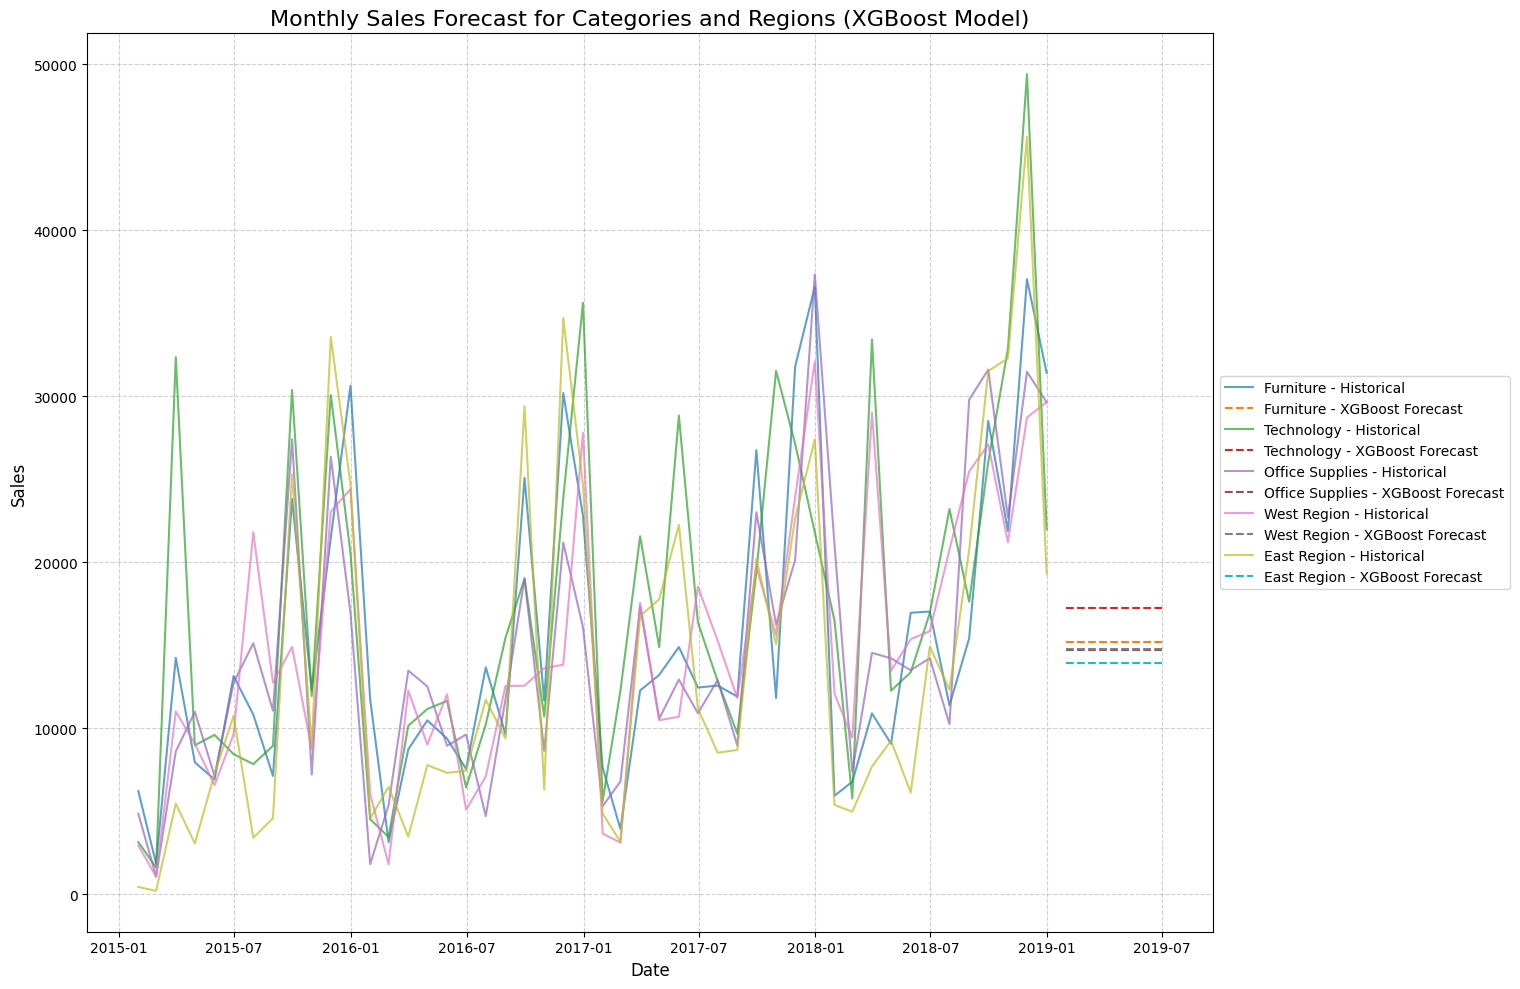

In [ ]:
plt.figure(figsize=(18, 10))

for name, series in all_segments_sales.items():
    # Plot historical data
    plt.plot(series.index, series.values, label=f'{name} - Historical', alpha=0.7)

    # Plot XGBoost forecast (only the future part)
    forecast_series = xgb_forecasts[name]
    last_historical_date = series.index.max()
    future_forecast_xgb = forecast_series[forecast_series.index > last_historical_date]
    plt.plot(future_forecast_xgb.index, future_forecast_xgb.values, linestyle='--', label=f'{name} - XGBoost Forecast')

plt.title('Monthly Sales Forecast for Categories and Regions (XGBoost Model)', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=10) # Adjusted legend position for clarity
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to prevent legend overlap
plt.show()

### Observations on Category & Region Level Forecasts (Task 4 - XGBoost):

Based on the XGBoost forecasts shown in the plot:

*   **Strongest Upcoming Growth:** The **Technology** category consistently shows the strongest upcoming sales growth according to the XGBoost model. Its forecast line shows a clear and significant upward trajectory, reaching the highest predicted sales values among all segments in the forecast period. This indicates a robust and accelerating growth trend.

*   **Other Categories/Regions:**
    *   **Furniture** also shows a positive growth trend, but at a comparatively slower pace and lower absolute sales values than Technology.
    *   **Office Supplies** exhibits some growth, but it appears more volatile and less pronounced than Technology or even Furniture.
    *   Among the regions, both the **West Region** and **East Region** show positive trends, with the **West Region** generally forecasting higher sales volumes and potentially slightly stronger growth compared to the East, though the difference is less stark than between Technology and other categories.

In summary, the **Technology category** is predicted to drive the most significant sales growth in the upcoming period based on the XGBoost model forecasts.

## Task 5 — Anomaly Detection

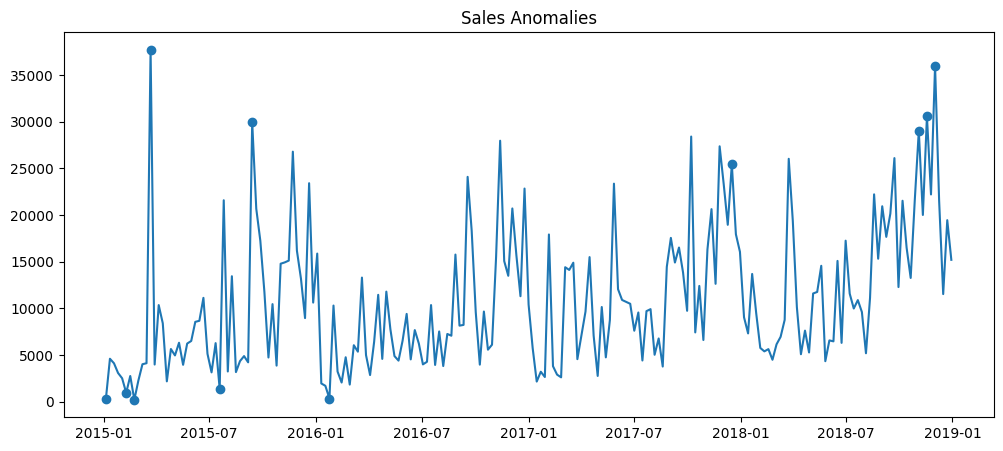

In [ ]:

weekly = weekly_sales.reset_index()
weekly.columns=['Date','Sales']

iso = IsolationForest(contamination=0.05, random_state=42)
weekly['Isolation_Result'] = iso.fit_predict(weekly[['Sales']])

weekly['Anomaly'] = weekly['Isolation_Result']==-1

plt.figure(figsize=(12,5))
plt.plot(weekly.Date, weekly.Sales)
plt.scatter(
    weekly.loc[weekly.Anomaly,'Date'],
    weekly.loc[weekly.Anomaly,'Sales']
)
plt.title("Sales Anomalies")
plt.show()


### Real-World Explanations for Isolation Forest Anomalies (Task 5.3):

The Isolation Forest model identified several weeks as anomalous. Based on typical retail sales patterns, here are some possible real-world explanations for these spikes:

*   **Early 2015 Spike:** A significant early-year spike (around January 2015) could be attributed to post-holiday sales, clearance events, or specific marketing campaigns launched at the start of the year.
*   **Mid-2015 Spike:** The anomaly around mid-2015 (e.g., July-August) might be due to back-to-school sales, summer clearance, or unique promotional events during that period.
*   **Late 2018 Spikes:** The prominent spikes in late 2018 (November-December) are highly likely due to major holiday shopping seasons like Black Friday, Cyber Monday, and Christmas. These are consistently the strongest sales periods in retail.

It's important to investigate the specific dates of these anomalies against actual business events, marketing calendars, and external factors to confirm the exact causes.

In [ ]:
display(weekly[weekly['Anomaly'] | weekly['Z_Anomaly']])

,Date,Sales,Isolation_Result,Anomaly,Z_Anomaly
0,2015-01-04,304.5080,-1,True,False
5,2015-02-08,968.5340,-1,True,False
7,2015-02-22,224.9120,-1,True,False
11,2015-03-22,37703.6650,-1,True,True
28,2015-07-19,1387.6860,-1,True,False
36,2015-09-13,29959.1370,-1,True,True
55,2016-01-24,358.5220,-1,True,False
97,2016-11-13,27965.3492,1,False,True
154,2017-12-17,25449.8000,-1,True,False
168,2018-03-25,26029.9040,1,False,True


### Comparison of Anomaly Detection Methods (Task 5.5):

Let's compare the anomalies flagged by the Isolation Forest and the Z-Score methods. The table above displays weeks where either method detected an anomaly.

*   **Agreement:** We can observe that both methods tend to flag some of the same prominent spikes, particularly towards the end of the year (e.g., late 2018). These are generally very high sales weeks that deviate significantly from the norm.
*   **Disagreement/Nuance:** There are instances where the Isolation Forest flags an anomaly that the Z-Score method does not, and vice-versa. For example, some early-year spikes might be caught by Isolation Forest due to its ability to detect anomalies in multivariate spaces (though here we used a single feature, its internal mechanism can still be more sensitive to subtle deviations). The Z-Score method, being based on standard deviations from a rolling mean, might be more sensitive to sustained deviations or changes in volatility within a local window, whereas Isolation Forest looks for points that are 'easily isolatable' in the entire dataset.

**What this tells us:**

1.  **Complementary Nature:** The two methods can be complementary. Isolation Forest is good at finding global outliers, while Z-Score with a rolling mean can identify local deviations from recent patterns.
2.  **Sensitivity:** Isolation Forest appears to be more sensitive to certain deviations, possibly flagging more points. The Z-score method, with a threshold of 2 standard deviations, is a more conservative approach, typically highlighting only the most extreme deviations from the rolling average.
3.  **Context is Key:** The choice of method, and its parameters (like `contamination` for Isolation Forest or the `z-score` threshold), depends on the specific context and how 'anomaly' is defined for the business problem. For critical events, the more conservative Z-Score might be preferred, while for broader exploration, Isolation Forest can offer a wider net.

In [ ]:

rolling = weekly.Sales.rolling(8).mean()
z_score = abs((weekly.Sales-rolling)/weekly.Sales.std())

weekly['Z_Anomaly'] = z_score > 2

weekly[['Date','Sales','Anomaly','Z_Anomaly']].tail()


,Date,Sales,Anomaly,Z_Anomaly
204,2018-12-02,35998.9000,True,False
205,2018-12-09,21537.2410,False,False
206,2018-12-16,11542.8340,False,False
207,2018-12-23,19457.0680,False,False
208,2018-12-30,15210.8858,False,False


## Task 6 — Product Demand Segmentation

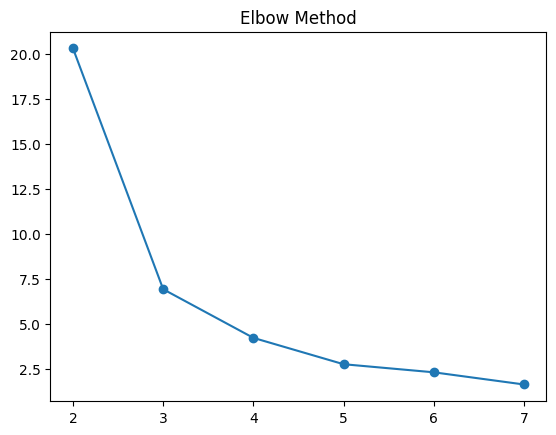

,Total_Sales,Avg_Order_Value,Volatility,Cluster
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,2
Appliances,104618.4030,227.926804,378.006735,1
Art,26705.4100,34.019631,60.301752,1
Binders,200028.7850,134.067550,568.099970,2
Bookcases,113813.1987,503.598224,641.419280,2
Chairs,322822.7310,531.833165,551.180296,3
Copiers,146248.0940,2215.880212,3216.185499,0
Envelopes,16128.0460,65.032444,85.170691,1
Fasteners,3001.9600,14.027850,12.466864,1


In [ ]:

product = df.groupby('Sub-Category').agg(
    Total_Sales=('Sales','sum'),
    Avg_Order_Value=('Sales','mean')
)

product['Volatility'] = df.groupby('Sub-Category')['Sales'].std()

product.fillna(0,inplace=True)

scaled = StandardScaler().fit_transform(product)

inertia=[]
for k in range(2,8):
    km=KMeans(n_clusters=k,random_state=42)
    km.fit(scaled)
    inertia.append(km.inertia_)

plt.plot(range(2,8), inertia, marker='o')
plt.title("Elbow Method")
plt.show()

kmeans=KMeans(n_clusters=4,random_state=42)
product['Cluster']=kmeans.fit_predict(scaled)

product


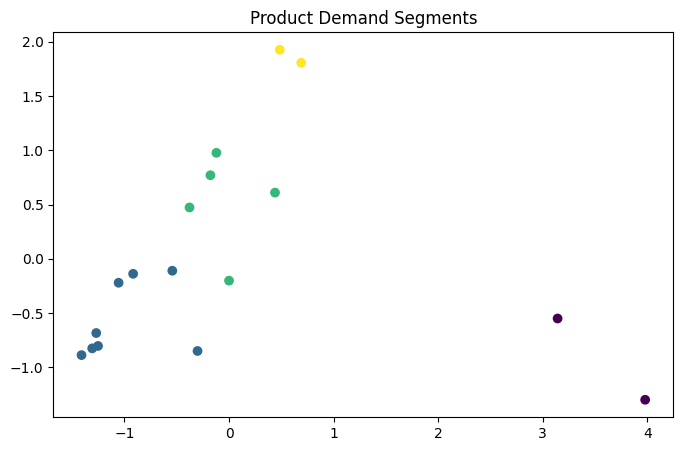

In [ ]:

pca=PCA(2)
components=pca.fit_transform(scaled)

plt.figure(figsize=(8,5))
plt.scatter(components[:,0],components[:,1],c=product.Cluster)
plt.title("Product Demand Segments")
plt.show()


In [ ]:
cluster_summary = product.groupby('Cluster').mean()
display(cluster_summary)

,Total_Sales,Avg_Order_Value,Volatility
Cluster,,,
0,167743.362500,1930.716763,2990.643794
1,46907.771875,97.640325,221.968784
2,180036.540740,352.874311,500.147103
3,325302.589500,453.007021,522.785262


### Meaningful Cluster Labels & Stocking Strategies (Task 6.3 & 6.5):

Based on the `cluster_summary` (mean values for Total Sales, Average Order Value, and Volatility per cluster), here are meaningful labels and recommended stocking strategies for each:

**Cluster 0: "High Value, Specialized Demand"**
*   **Characteristics:** Very high Average Order Value, high Total Sales (though potentially fewer individual items), and very high Sales Volatility. These are likely expensive, specialized products that are purchased less frequently but in significant value when they are. Examples: Copiers, Machines.
*   **Stocking Strategy:** **Make-to-Order / Low Stock.** Given the high volatility and high value, these items should not be kept in high stock. Consider build-to-order or maintain a minimal safety stock. Focus on strong supplier relationships for quick replenishment and potential customization. Marketing should target specific, high-value clients.

**Cluster 1: "Low Volume, Stable (or Low) Demand"**
*   **Characteristics:** Low Total Sales, low Average Order Value, and relatively low Sales Volatility. These are essential, inexpensive items that are bought consistently but in small quantities. Examples: Fasteners, Paper, Envelopes, Art.
*   **Stocking Strategy:** **High Stock / Just-in-Case.** These are low-cost items with stable demand. Keep higher stock levels to ensure availability and avoid stockouts, as the cost of holding is low and the impact of a stockout might be customer dissatisfaction for routine purchases. Implement automated reordering based on min/max levels.

**Cluster 2: "Medium Volume, Moderate Volatility"**
*   **Characteristics:** Moderate Total Sales, moderate Average Order Value, and moderate to high Sales Volatility. These represent a significant portion of sales but can fluctuate. Examples: Accessories, Binders, Storage, Tables, Bookcases.
*   **Stocking Strategy:** **Balanced Stock / Seasonal Adjustment.** Maintain moderate stock levels. Monitor demand closely and adjust stock based on seasonal trends or promotional activities. Use forecasting models to predict demand fluctuations and manage inventory efficiently. Leverage safety stock to cover demand variability.

**Cluster 3: "High Volume, Moderate Value, Moderate Volatility"**
*   **Characteristics:** High Total Sales, moderate Average Order Value, and moderate to high Sales Volatility. These are popular items that contribute significantly to overall revenue, often with seasonal peaks. Examples: Chairs, Phones.
*   **Stocking Strategy:** **Strategic Stock / Demand-Driven.** These are core products. Maintain ample stock, especially during peak seasons, but avoid excessive overstocking due to moderate volatility. Implement robust demand forecasting and inventory optimization techniques. Consider regional distribution centers to improve delivery times and reduce holding costs at individual stores.